In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub
import os
from google.colab import drive

In [13]:
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("aima138/17flowerclasses")
print(f"Dataset downloaded to: {dataset_path}")

print(f"Contents of {dataset_path}:")
print(os.listdir(dataset_path))

folder_name = os.listdir(dataset_path)[0]
print(f"Contents inside {folder_name}:")
print(os.listdir(os.path.join(dataset_path, folder_name)))

TRAIN_DIR = os.path.join(dataset_path, "17flowerclasses", "train")
TEST_DIR = os.path.join(dataset_path, "17flowerclasses", "test")

Using Colab cache for faster access to the '17flowerclasses' dataset.
Dataset downloaded to: /kaggle/input/17flowerclasses
Contents of /kaggle/input/17flowerclasses:
['17flowerclasses']
Contents inside 17flowerclasses:
['test', 'train']


In [14]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("\nLoading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data:")
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Test Data:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Loading Training Data:
Found 1190 files belonging to 17 classes.
Using 952 files for training.

Loading Validation Data:
Found 1190 files belonging to 17 classes.
Using 238 files for validation.

Loading Test Data:
Found 170 files belonging to 17 classes.
Classes: ['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']


In [15]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds_opt = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_opt = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_opt = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
], name="data_augmentation")


In [17]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(17, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, outputs)

In [18]:
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(tl_model.count_params())

early_stop_phase1 = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print("Training: ")
history_phase1 = tl_model.fit(
    train_ds_opt,
    validation_data=val_ds_opt,
    epochs=20,
    callbacks=[early_stop_phase1]
)


2279761
Training: 
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - accuracy: 0.2153 - loss: 2.5298 - val_accuracy: 0.6218 - val_loss: 1.5161
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.5830 - loss: 1.3435 - val_accuracy: 0.7857 - val_loss: 0.9256
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7342 - loss: 0.9203 - val_accuracy: 0.8361 - val_loss: 0.7058
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8015 - loss: 0.6996 - val_accuracy: 0.8319 - val_loss: 0.6197
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8309 - loss: 0.5807 - val_accuracy: 0.8445 - val_loss: 0.5288
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8592 - loss: 0.5164 - val_accuracy: 0.8908 - val_loss: 0.4672
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8750 - loss: 0.4705 - val_accuracy: 0.8655 - val_loss: 0.4508
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8876 - loss: 0.3882 - val

In [19]:
print("Fine-Tuning:")
base_model.trainable = True

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_phase2 = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history_phase2 = tl_model.fit(
    train_ds_opt,
    validation_data=val_ds_opt,
    epochs=20,
    callbacks=[early_stop_phase2]
)


Fine-Tuning:
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 345ms/step - accuracy: 0.6376 - loss: 1.2598 - val_accuracy: 0.9118 - val_loss: 0.2744
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.6744 - loss: 1.0085 - val_accuracy: 0.9034 - val_loss: 0.2650
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 284ms/step - accuracy: 0.7321 - loss: 0.8498 - val_accuracy: 0.9160 - val_loss: 0.2570
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 287ms/step - accuracy: 0.7847 - loss: 0.6944 - val_accuracy: 0.9118 - val_loss: 0.2528
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - accuracy: 0.8204 - loss: 0.5806 - val_accuracy: 0.9160 - val_loss: 0.2491
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.8550 - loss: 0.4992 - val_accuracy: 0.9160 - val_loss: 0.2429
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.8655 - loss: 0.4372 - val_accuracy: 0.9160 - val_loss: 0.2371
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.8782 - loss: 0.4131 - va

In [20]:
print("Testing: ")
test_loss, test_acc = tl_model.evaluate(test_ds_opt)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Testing: 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8941 - loss: 0.3791

 Test Accuracy: 89.41%
Test Loss: 0.3791


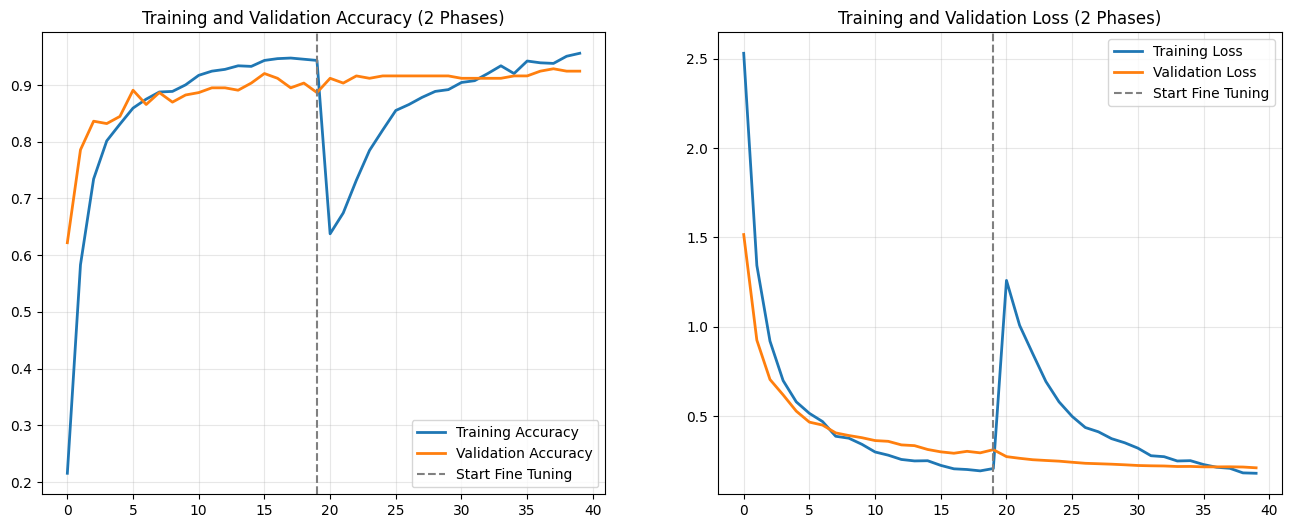

In [21]:
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy', linewidth=2)

plt.axvline(x=len(history_phase1.history['accuracy'])-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (2 Phases)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history_phase1.history['loss'])-1, color='gray', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (2 Phases)')
plt.grid(True, alpha=0.3)

plt.show()

In [22]:
print("\nGenerating Predictions for Classification Report and Confusion Matrix...")
y_true = []
y_pred = []

for images, labels in test_ds_opt:
    predictions = tl_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

class_names = test_ds.class_names
print("CLASSIFICATION REPORT (Transfer Learning): ")
print(classification_report(y_true, y_pred, target_names=class_names))


Generating Predictions for Classification Report and Confusion Matrix...
CLASSIFICATION REPORT (Transfer Learning): 
              precision    recall  f1-score   support

    Bluebell       1.00      0.90      0.95        10
   ButterCup       1.00      0.90      0.95        10
   ColtsFoot       0.80      0.80      0.80        10
     Cowslip       1.00      0.50      0.67        10
      Crocus       0.83      1.00      0.91        10
    Daffodil       0.73      0.80      0.76        10
       Daisy       0.91      1.00      0.95        10
   Dandelion       1.00      0.90      0.95        10
  Fritillary       1.00      0.90      0.95        10
        Iris       1.00      0.90      0.95        10
  LilyValley       0.91      1.00      0.95        10
       Pansy       1.00      0.90      0.95        10
    Snowdrop       0.75      0.90      0.82        10
   Sunflower       1.00      1.00      1.00        10
   Tigerlily       1.00      0.90      0.95        10
  WindFlower     

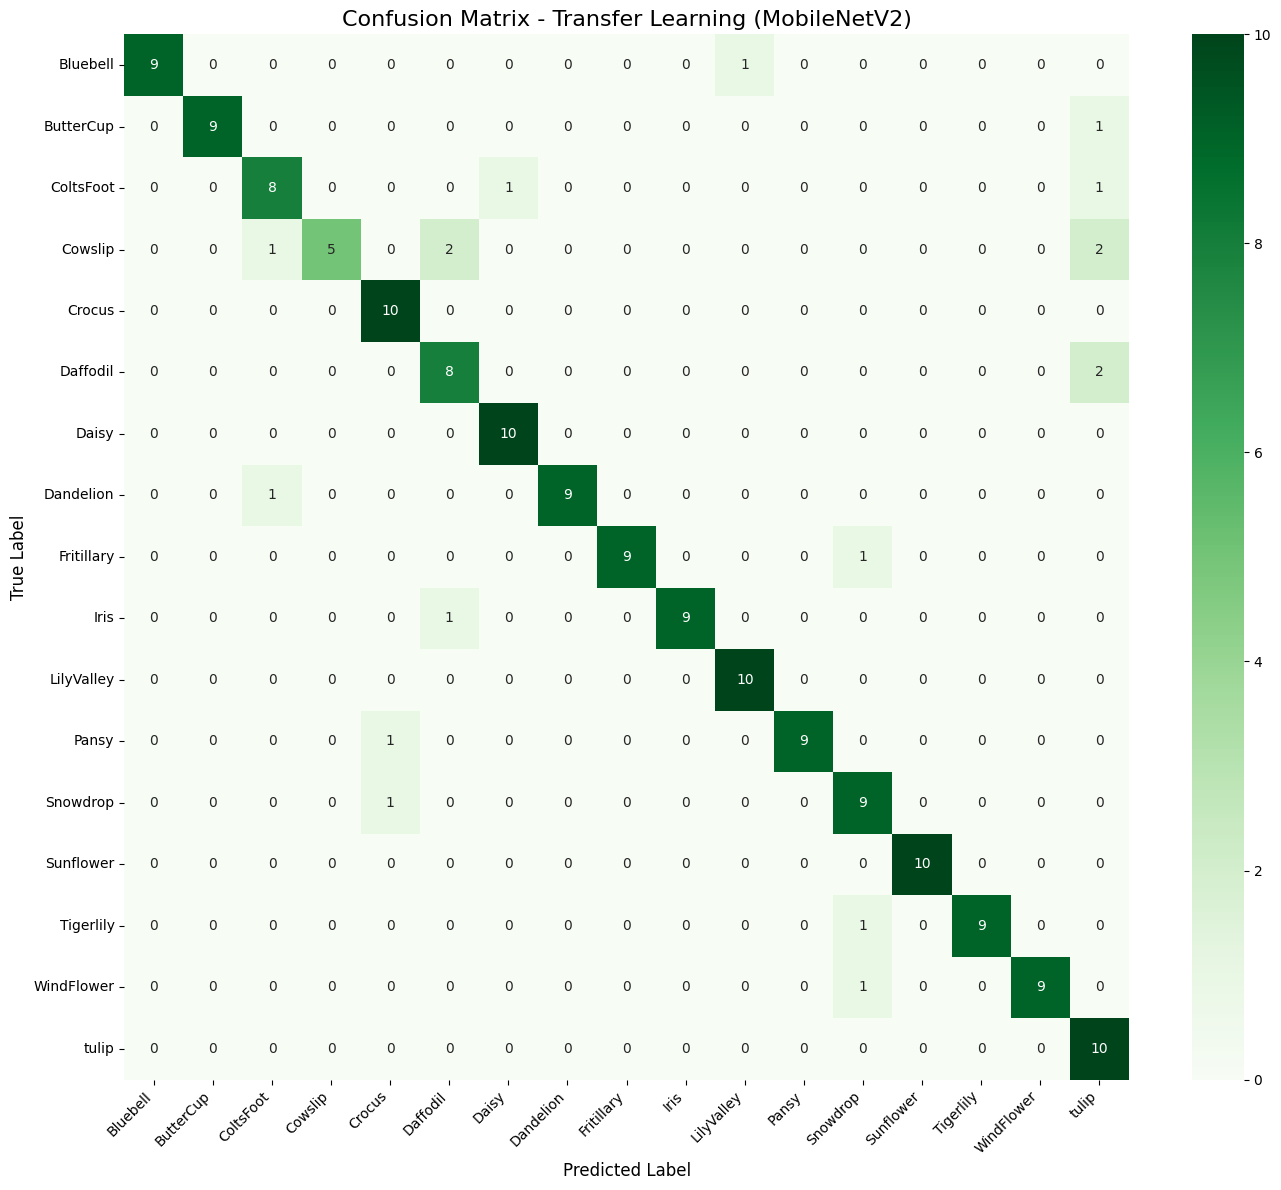

In [23]:
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Transfer Learning (MobileNetV2)', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
test_images = ['01.jpg', '02.jpg', '03.jpg', '04.jpg']

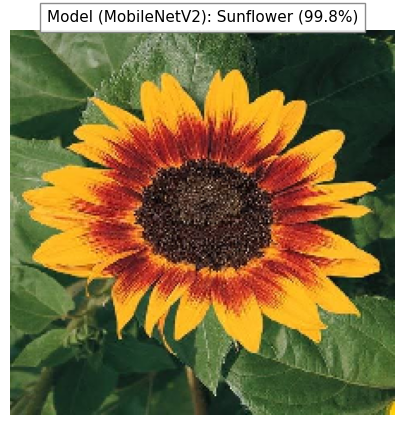

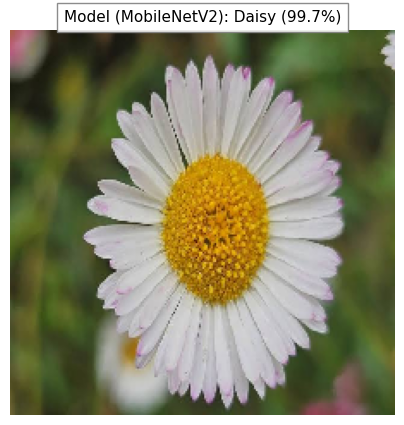

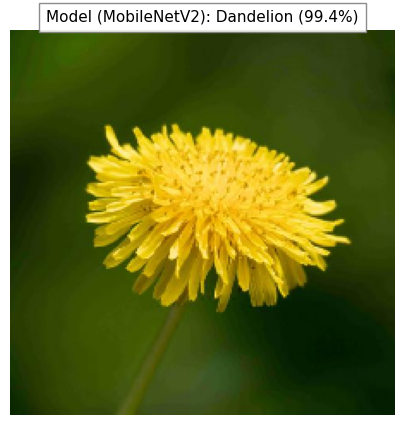

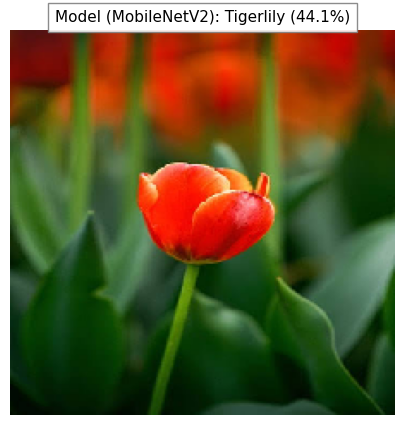

In [28]:
from tensorflow.keras.preprocessing import image
for img_name in test_images:

    img = image.load_img(img_name, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    try:
        pred_tl = tl_model.predict(img_array, verbose=0)
        class_tl = class_names[np.argmax(pred_tl[0])]
        conf_tl = np.max(pred_tl[0]) * 100
    except NameError:
         class_tl, conf_tl = "model error", 0

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")

    title_text = (
        f"Model (MobileNetV2): {class_tl} ({conf_tl:.1f}%)"
    )
    plt.title(title_text, loc='center', fontsize=11, color='black',
              bbox=dict(facecolor='white', alpha=0.9, pad=5, edgecolor='gray'))
    plt.show()